# Notebook 08c — XGBoost: Weather Effects on Cycling Demand

## 0. Imports & Setup

In [58]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost", "shap"])

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [59]:
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

COLORS = {
    "commuter" : "#2196F3",
    "mixed"    : "#FFC107",
    "leisure"  : "#F44336",
}

panel = pd.read_parquet(PROCESSED / "analysis_panel.parquet")

site_cls = pd.read_parquet(PROCESSED / "site_classification.parquet")[["site ID", "commute_score", "site_type"]]
panel = panel.merge(site_cls, on="site ID", how="left")
panel["site_type"] = panel["site_type"].fillna("unclassified")

panel_good = panel[
    (panel["low_coverage"] == False) &
    (panel["aantal"].notna()) &
    (panel["temp_avg"].notna())
].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

print(f"Date range : {panel_good['date'].min().date()}  \u2192  {panel_good['date'].max().date()}")
print(f"Total rows : {len(panel_good):,}")
print("\nRows per year:")
print(panel_good['date'].dt.year.value_counts().sort_index().to_string())
print("\nsite_type distribution:")
print(panel_good['site_type'].value_counts().to_string())

Date range : 2023-01-01  →  2025-12-31
Total rows : 144,338

Rows per year:
date
2023    47836
2024    48351
2025    48151

site_type distribution:
site_type
commuter    73141
leisure     43464
mixed       27733


## 0c. Outlier Blacklist, Event Flags & Train/Test Split

Based on the IQR audit above, classify each candidate:
- **`remove_dates`** — likely data/sensor errors: set `aantal` to NaN
- **`event_dates`** — confirmed real events: keep value, flag with `is_event_day = 1`

In [60]:
remove_dates = [
    (105, '2023-03-03'),
    (85,  '2024-07-25'),
    (20,  '2024-06-02'),
    (140, '2024-07-13'),
    (129, '2024-08-12'),
    (78,  '2023-07-01'),
    (50,  '2024-09-18'),
    (94,  '2023-08-20'),
    (33,  '2023-01-20'),
    (81,  '2024-08-18'),
    (83,  '2024-03-19'),
    (83,  '2024-03-27'), (83,  '2024-03-28'), (83,  '2024-03-29'),
    (83,  '2024-03-30'), (83,  '2024-03-31'), (83,  '2024-04-01'),
    (83,  '2024-04-02'), (83,  '2024-04-03'), (83,  '2024-04-04'),
    (83,  '2024-04-05'), (83,  '2024-04-06'), (83,  '2024-04-07'),
    (83,  '2024-04-08'), (83,  '2024-04-09'), (83,  '2024-04-10'),
]

event_dates = [
    (70,  '2023-09-16'), (70,  '2024-09-21'),
    (85,  '2024-07-07'), (85,  '2024-07-21'),
    (72,  '2024-05-08'), (51,  '2024-05-08'),
    (43,  '2023-05-28'), (44,  '2023-05-28'),
    (28,  '2024-04-06'), (28,  '2024-04-13'), (28,  '2024-04-14'),
    (28,  '2023-04-30'), (28,  '2023-05-01'), (28,  '2023-05-04'),
    (34,  '2024-04-06'), (34,  '2023-04-30'), (34,  '2023-06-03'),
    (14,  '2023-09-24'), (14,  '2024-09-22'),
    (48,  '2024-09-18'), (48,  '2024-09-19'), (48,  '2024-09-20'),
    (48,  '2024-09-21'), (48,  '2024-09-22'),
]

remove_set = set((s, d) for s, d in remove_dates)
event_set  = set((s, d) for s, d in event_dates)

remove_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in remove_set, axis=1
)
panel_good.loc[remove_mask, 'aantal'] = np.nan
print(f'Removed {remove_mask.sum()} extreme outlier rows')

event_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in event_set, axis=1
)
panel_good['is_event_day'] = event_mask.astype(int)
print(f'Flagged {event_mask.sum()} recurring event days')

print("\n" + "─" * 40)
train = panel_good[panel_good["date"].dt.year.isin([2023, 2024])].copy()
test  = panel_good[panel_good["date"].dt.year == 2025].copy()

# Split by year first — must precede offset computation to avoid leakage
train_2023 = train[train["date"].dt.year == 2023].copy()
val_2024   = train[train["date"].dt.year == 2024].copy()

# Offset for early-stopping validation: computed from 2023 only (no 2024 leakage)
site_offset_val = (
    train_2023.groupby("site ID")["aantal"]
    .apply(lambda x: np.log1p(x).mean())
    .reset_index()
    .rename(columns={"aantal": "site_offset"})
)

# Offset for final model & 2025 test: computed from 2023+2024
site_offset_test = (
    train.groupby("site ID")["aantal"]
    .apply(lambda x: np.log1p(x).mean())
    .reset_index()
    .rename(columns={"aantal": "site_offset"})
)

train_2023 = train_2023.merge(site_offset_val,  on="site ID", how="left")
val_2024   = val_2024.merge(site_offset_val,    on="site ID", how="left")
train      = train.merge(site_offset_test,      on="site ID", how="left")
test       = test.merge(site_offset_test,       on="site ID", how="left")
panel_good = panel_good.merge(site_offset_test, on="site ID", how="left")

# One-hot encode site_type (static per site, no leakage risk)
SITE_TYPE_COLS = [f"site_type_{t}" for t in sorted(panel_good["site_type"].unique())]

def _add_site_dummies(df):
    dummies = pd.get_dummies(df["site_type"], prefix="site_type").astype(int)
    for col in SITE_TYPE_COLS:
        df[col] = dummies[col] if col in dummies.columns else 0
    return df

panel_good = _add_site_dummies(panel_good)
train      = _add_site_dummies(train)
test       = _add_site_dummies(test)
train_2023 = _add_site_dummies(train_2023)
val_2024   = _add_site_dummies(val_2024)

print(f"Train size : {len(train):,} rows (2023–2024)")
print(f"Test size  : {len(test):,} rows (2025)")
print(f"Site-type dummies: {SITE_TYPE_COLS}")

Removed 26 extreme outlier rows
Flagged 24 recurring event days

────────────────────────────────────────
Train size : 96,187 rows (2023–2024)
Test size  : 48,151 rows (2025)
Site-type dummies: ['site_type_commuter', 'site_type_leisure', 'site_type_mixed']


## 1. Feature Engineering

In [61]:
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    train[col] = train[col].astype(int)
    test[col]  = test[col].astype(int)
    panel_good[col] = panel_good[col].astype(int)

ALL_FEATURES = [
    "temp_avg", "precip_total", "wind_avg",
    "sunshine_min", "humidity_avg",
    "temp_avg_lag1", "precip_total_lag1", "wind_avg_lag1",
    "dayofweek", "month",
    "is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day",
    "commute_score", "lat", "long",
] + SITE_TYPE_COLS

print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"Train shape: {train.shape} |  Test shape: {test.shape}")

Features (20): ['temp_avg', 'precip_total', 'wind_avg', 'sunshine_min', 'humidity_avg', 'temp_avg_lag1', 'precip_total_lag1', 'wind_avg_lag1', 'dayofweek', 'month', 'is_weekend', 'is_public_holiday', 'is_school_holiday', 'is_event_day', 'commute_score', 'lat', 'long', 'site_type_commuter', 'site_type_leisure', 'site_type_mixed']
Train shape: (96187, 61) |  Test shape: (48151, 61)


## 2. Prepare Feature Matrix

XGBoost handles raw (unscaled) features natively — no StandardScaler needed.

In [62]:
def make_X_y_with_offset(df, features):
    cols = features + ["aantal", "site_offset"]
    df_clean = df[cols].dropna()
    X     = df_clean[features].values.astype(float)
    y_raw = df_clean["aantal"].values.astype(float)
    y_adj = np.log1p(y_raw) - df_clean["site_offset"].values
    return X, y_adj, y_raw, df_clean

# Final model data (2023+2024 → 2025): carries site_offset_test
X_train_full, y_train_full, y_train_raw_full, train_clean_full = make_X_y_with_offset(train, ALL_FEATURES)
X_test_full,  y_test_full,  y_test_raw_full,  test_clean_full  = make_X_y_with_offset(test,  ALL_FEATURES)

# Early-stopping split (2023 → 2024): carries site_offset_val (no leakage)
X_tr_full,  y_tr_full,  _,             _              = make_X_y_with_offset(train_2023, ALL_FEATURES)
X_val_full, y_val_full, y_val_raw_full, val_clean_full = make_X_y_with_offset(val_2024,   ALL_FEATURES)

print(f"Train (2023) : {X_tr_full.shape[0]:,} rows")
print(f"Val   (2024) : {X_val_full.shape[0]:,} rows")
print(f"Test  (2025) : {X_test_full.shape[0]:,} rows")

Train (2023) : 47,709 rows
Val   (2024) : 48,329 rows
Test  (2025) : 48,151 rows


## 3. Model A — Full XGBoost (all stations)

In [63]:
def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    print(f"  {label:<12}: MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}")
    return mae, rmse, r2

XGB_PARAMS = dict(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,        # row sampling to reduce overfitting
    colsample_bytree=0.8, # feature sampling to reduce overfitting
    min_child_weight=10,  # minimum sum of instance weight needed in a child to reduce overfitting
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=50, # early stopping on validation set to find optimal n_estimators
    eval_metric="rmse",
    random_state=42,
)

# Phase 1: find best_iteration with clean 2023 → 2024 validation (no leakage)
xgb_es = XGBRegressor(**XGB_PARAMS)
xgb_es.fit(
    X_tr_full, y_tr_full,
    eval_set=[(X_val_full, y_val_full)],
    verbose=100,
)
best_iter_full = xgb_es.best_iteration
print(f"Best iteration (early stopping): {best_iter_full}")

# Val performance with clean offset
offset_val_full = val_clean_full["site_offset"].values
y_pred_val_full = np.clip(np.expm1(xgb_es.predict(X_val_full) + offset_val_full), 0, None)

# Phase 2: retrain on 2023+2024 with fixed n_estimators (site_offset_test)
xgb_full = XGBRegressor(**{**XGB_PARAMS, "n_estimators": best_iter_full + 1, "early_stopping_rounds": None})
xgb_full.fit(X_train_full, y_train_full, verbose=False)

# Test performance (2025)
offset_test_full = test_clean_full["site_offset"].values
y_pred_full_raw  = xgb_full.predict(X_test_full)
y_pred_full      = np.clip(np.expm1(y_pred_full_raw + offset_test_full), 0, None)

print("\n" + "=" * 52)
print("Full XGB:")
val_mae_f,  val_rmse_f,  val_r2_f  = evaluate(y_val_raw_full,  y_pred_val_full, "Val  (2024)")
test_mae, test_rmse, test_r2 = evaluate(y_test_raw_full, y_pred_full,    "Test (2025)")
print("=" * 52)

[0]	validation_0-rmse:0.83780
[100]	validation_0-rmse:0.74193
[104]	validation_0-rmse:0.74467
Best iteration (early stopping): 54

Full XGB:
  Val  (2024) : MAE=116.8  RMSE=252.5  R²=0.843
  Test (2025) : MAE=130.0  RMSE=271.7  R²=0.853


## 4. Model B — Commuter XGBoost

In [64]:
train_c = train[train["site_type"] == "commuter"].copy()
test_c  = test[test["site_type"]   == "commuter"].copy()

X_train_c, y_train_c, y_train_c_raw, train_clean_c = make_X_y_with_offset(train_c, ALL_FEATURES)
X_test_c,  y_test_c,  y_test_c_raw,  test_clean_c  = make_X_y_with_offset(test_c,  ALL_FEATURES)

# Early-stopping split: filter from pre-split frames (site_offset_val, no leakage)
train_c_2023 = train_2023[train_2023["site_type"] == "commuter"].copy()
val_c_2024   = val_2024[val_2024["site_type"]     == "commuter"].copy()

X_tr_c,  y_tr_c,  _,           _            = make_X_y_with_offset(train_c_2023, ALL_FEATURES)
X_val_c, y_val_c, y_val_c_raw, val_clean_c  = make_X_y_with_offset(val_c_2024,   ALL_FEATURES)

print(f"  Train (2023) : {X_tr_c.shape[0]:,} rows")
print(f"  Val   (2024) : {X_val_c.shape[0]:,} rows")
print(f"  Test  (2025) : {X_test_c.shape[0]:,} rows")

# Phase 1: find best_iteration
xgb_es_c = XGBRegressor(**XGB_PARAMS)
xgb_es_c.fit(
    X_tr_c, y_tr_c,
    eval_set=[(X_val_c, y_val_c)],
    verbose=100,
)
best_iter_c = xgb_es_c.best_iteration
print(f"Best iteration (early stopping): {best_iter_c}")

# Val performance with clean offset
offset_val_c = val_clean_c["site_offset"].values
y_pred_c_val = np.clip(np.expm1(xgb_es_c.predict(X_val_c) + offset_val_c), 0, None)

# Phase 2: retrain on 2023+2024
xgb_commuter = XGBRegressor(**{**XGB_PARAMS, "n_estimators": best_iter_c + 1, "early_stopping_rounds": None})
xgb_commuter.fit(X_train_c, y_train_c, verbose=False)

# Test performance (2025)
offset_test_c = test_clean_c["site_offset"].values
y_pred_c_raw  = xgb_commuter.predict(X_test_c)
y_pred_c      = np.clip(np.expm1(y_pred_c_raw + offset_test_c), 0, None)

print("Commuter XGB:")
val_mae_c, val_rmse_c, val_r2_c = evaluate(y_val_c_raw, y_pred_c_val, "Val  (2024)")
mae_c, rmse_c, r2_c = evaluate(y_test_c_raw, y_pred_c,     "Test (2025)")

  Train (2023) : 24,345 rows
  Val   (2024) : 24,360 rows
  Test  (2025) : 24,350 rows
[0]	validation_0-rmse:0.61951
[100]	validation_0-rmse:0.50331
[103]	validation_0-rmse:0.50333
Best iteration (early stopping): 53
Commuter XGB:
  Val  (2024) : MAE=102.8  RMSE=194.9  R²=0.916
  Test (2025) : MAE=132.1  RMSE=279.3  R²=0.875


## 5. Model C — Leisure XGBoost

In [65]:
train_l = train[train["site_type"] == "leisure"].copy()
test_l  = test[test["site_type"]   == "leisure"].copy()

X_train_l, y_train_l, y_train_l_raw, train_clean_l = make_X_y_with_offset(train_l, ALL_FEATURES)
X_test_l,  y_test_l,  y_test_l_raw,  test_clean_l  = make_X_y_with_offset(test_l,  ALL_FEATURES)

# Early-stopping split: filter from pre-split frames (site_offset_val, no leakage)
train_l_2023 = train_2023[train_2023["site_type"] == "leisure"].copy()
val_l_2024   = val_2024[val_2024["site_type"]     == "leisure"].copy()

X_tr_l,  y_tr_l,  _,           _            = make_X_y_with_offset(train_l_2023, ALL_FEATURES)
X_val_l, y_val_l, y_val_l_raw, val_clean_l  = make_X_y_with_offset(val_l_2024,   ALL_FEATURES)

print(f"  Train (2023) : {X_tr_l.shape[0]:,} rows")
print(f"  Val   (2024) : {X_val_l.shape[0]:,} rows")
print(f"  Test  (2025) : {X_test_l.shape[0]:,} rows")

# Phase 1: find best_iteration
xgb_es_l = XGBRegressor(**XGB_PARAMS)
xgb_es_l.fit(
    X_tr_l, y_tr_l,
    eval_set=[(X_val_l, y_val_l)],
    verbose=100,
)
best_iter_l = xgb_es_l.best_iteration
print(f"Best iteration (early stopping): {best_iter_l}")

# Val performance with clean offset
offset_val_l = val_clean_l["site_offset"].values
y_pred_l_val = np.clip(np.expm1(xgb_es_l.predict(X_val_l) + offset_val_l), 0, None)

# Phase 2: retrain on 2023+2024
xgb_leisure = XGBRegressor(**{**XGB_PARAMS, "n_estimators": best_iter_l + 1, "early_stopping_rounds": None})
xgb_leisure.fit(X_train_l, y_train_l, verbose=False)

# Test performance (2025)
offset_test_l = test_clean_l["site_offset"].values
y_pred_l_raw  = xgb_leisure.predict(X_test_l)
y_pred_l      = np.clip(np.expm1(y_pred_l_raw + offset_test_l), 0, None)

print("Leisure XGB:")
val_mae_l, val_rmse_l, val_r2_l = evaluate(y_val_l_raw, y_pred_l_val, "Val  (2024)")
mae_l, rmse_l, r2_l = evaluate(y_test_l_raw, y_pred_l,     "Test (2025)")

print("\n" + "=" * 60)
print("MODEL COMPARISON (Test Set, 2025)")
print("=" * 60)
print(f"{'Metric':<6} | {'Full XGB':>10} | {'Commuter XGB':>13} | {'Leisure XGB':>12}")
print("-" * 60)
print(f"{'MAE':<6} | {test_mae:>10.1f} | {mae_c:>13.1f} | {mae_l:>12.1f}")
print(f"{'RMSE':<6} | {test_rmse:>10.1f} | {rmse_c:>13.1f} | {rmse_l:>12.1f}")
_r2 = "R²"
print(f"{_r2:<6} | {test_r2:>10.3f} | {r2_c:>13.3f} | {r2_l:>12.3f}")
print("=" * 60)

  Train (2023) : 14,281 rows
  Val   (2024) : 14,617 rows
  Test  (2025) : 14,526 rows
[0]	validation_0-rmse:0.87333
[100]	validation_0-rmse:0.71582
[200]	validation_0-rmse:0.71148
[300]	validation_0-rmse:0.71016
[359]	validation_0-rmse:0.71053
Best iteration (early stopping): 309
Leisure XGB:
  Val  (2024) : MAE=106.7  RMSE=247.9  R²=0.839
  Test (2025) : MAE=116.2  RMSE=267.7  R²=0.813

MODEL COMPARISON (Test Set, 2025)
Metric |   Full XGB |  Commuter XGB |  Leisure XGB
------------------------------------------------------------
MAE    |      130.0 |         132.1 |        116.2
RMSE   |      271.7 |         279.3 |        267.7
R²     |      0.853 |         0.875 |        0.813


## 6. SHAP Analysis

SHAP values computed on 3000 random test observations for speed.

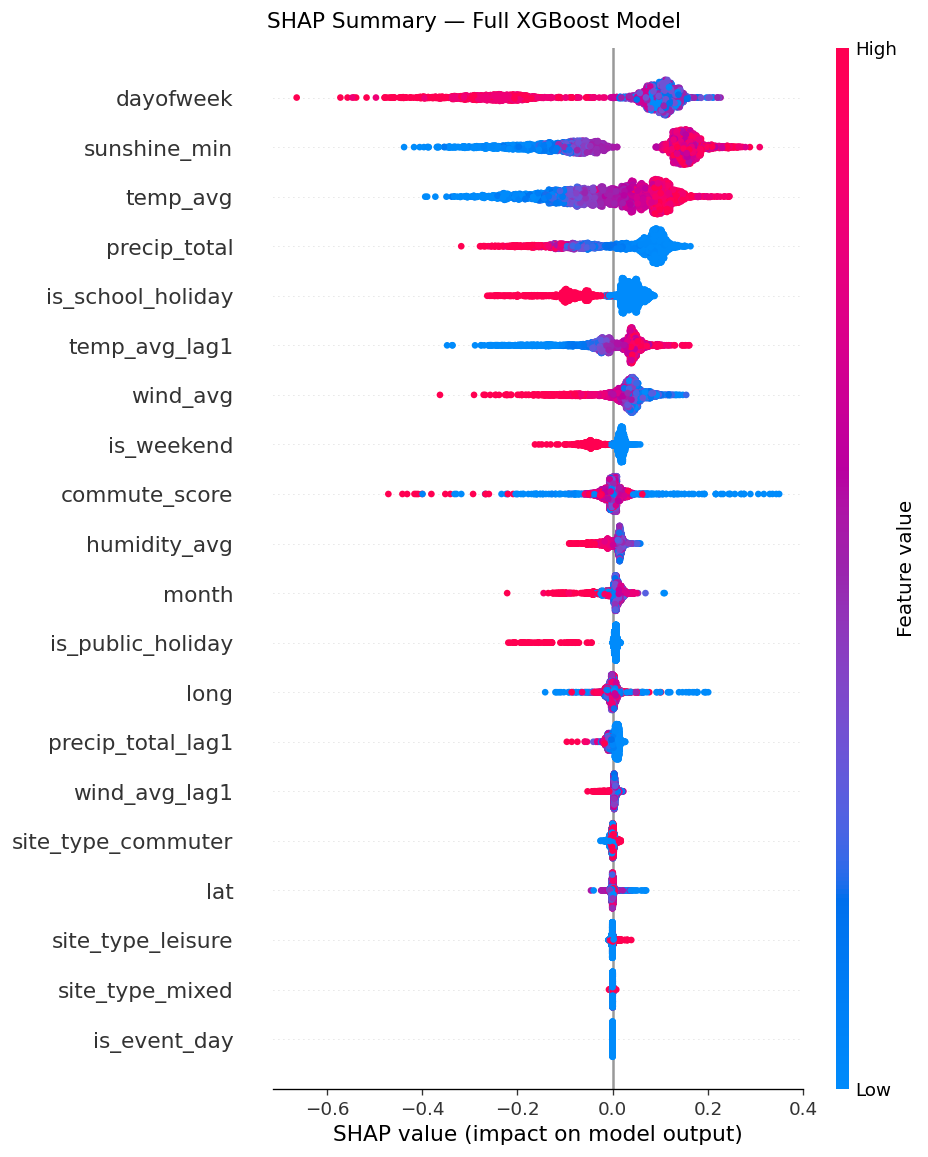

08c_shap_summary_full.png saved.


In [66]:
N_SHAP = 3000
rng = np.random.default_rng(42)

# sample subset for SHAP 
idx_shap_full  = rng.choice(len(X_test_full), size=min(N_SHAP, len(X_test_full)), replace=False)
X_shap_full    = X_test_full[idx_shap_full]

explainer_full   = shap.TreeExplainer(xgb_full)
shap_values_full = explainer_full.shap_values(X_shap_full)

# Fig A — SHAP summary plot (full model)
shap.summary_plot(shap_values_full, X_shap_full, feature_names=ALL_FEATURES, show=False)
fig_a = plt.gcf()
fig_a.suptitle("SHAP Summary \u2014 Full XGBoost Model", fontsize=13, y=1.01)
fig_a.savefig(FIGS / "08c_shap_summary_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("08c_shap_summary_full.png saved.")

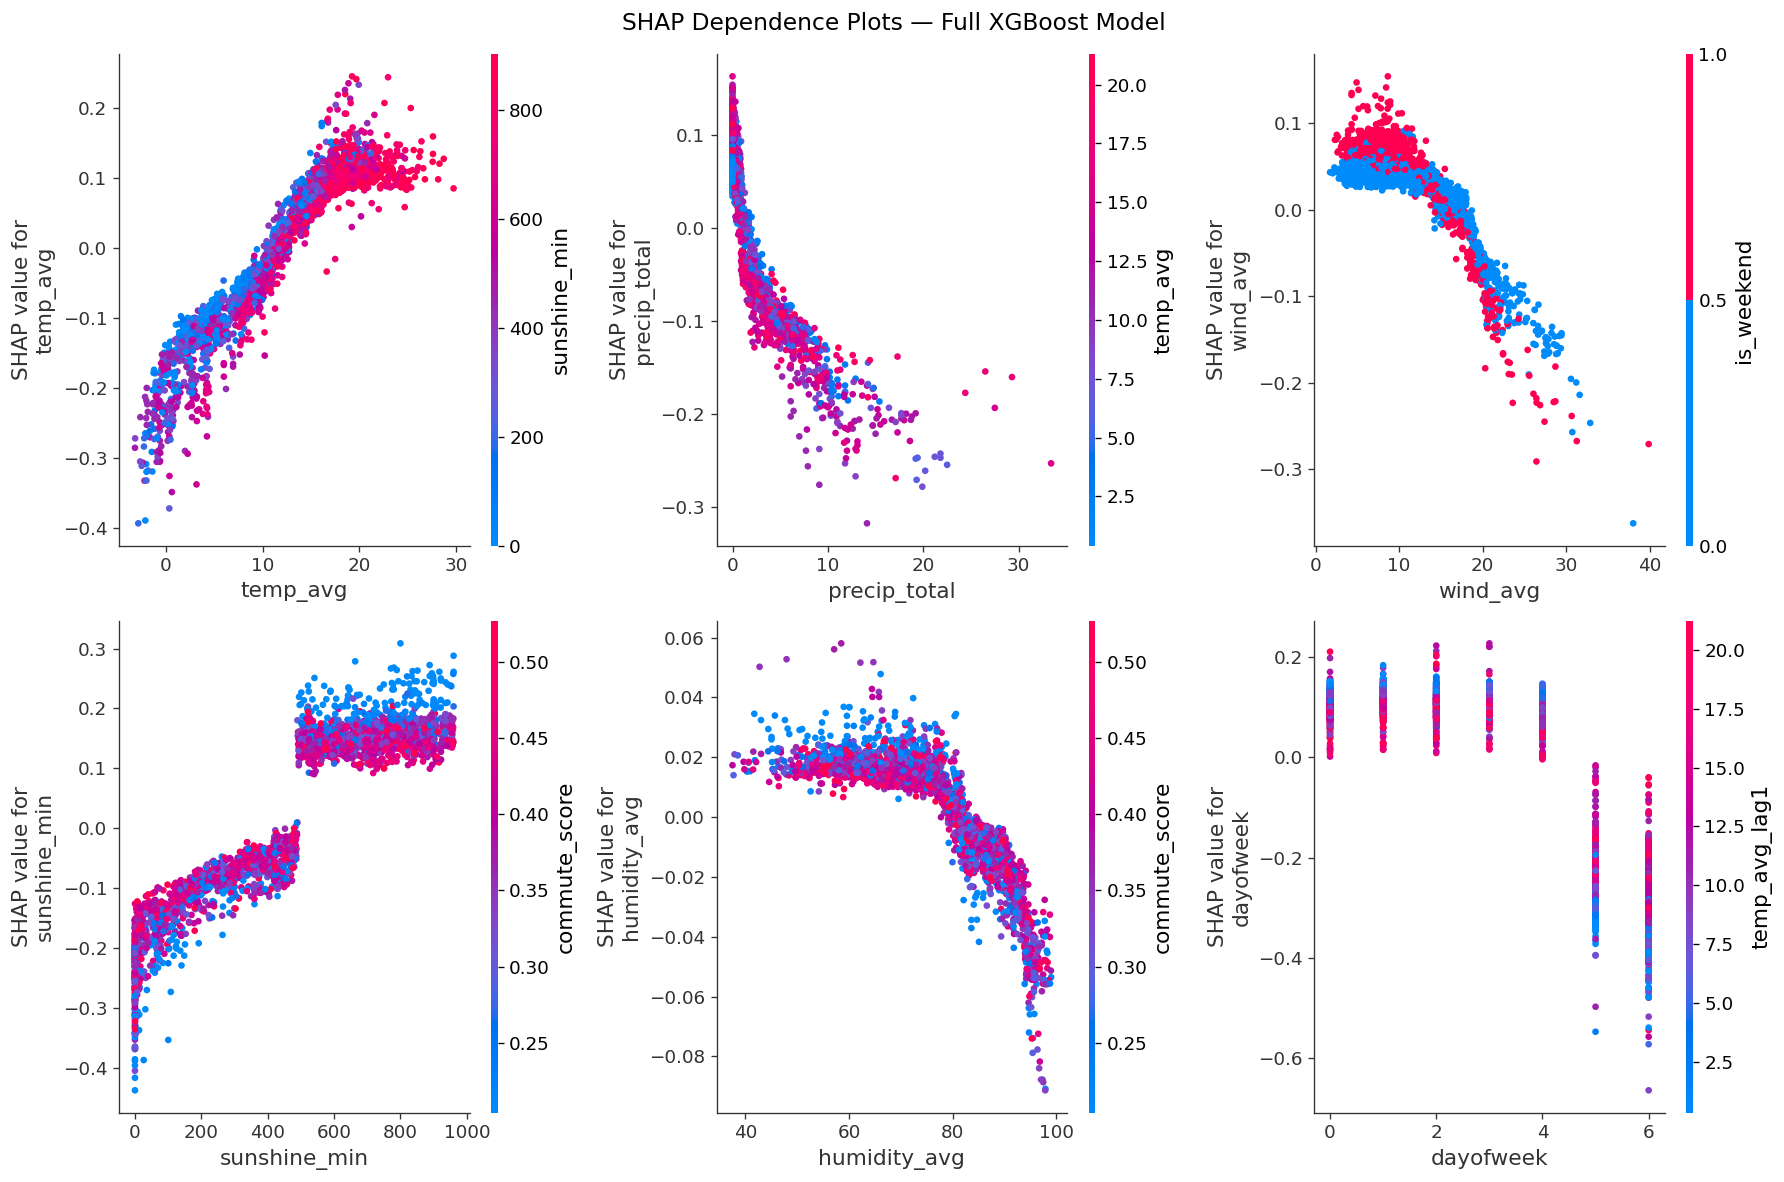

08c_shap_dependence_full.png saved.


In [67]:
# Fig B — SHAP dependence plots (2×3 grid, full model)
dep_features = ["temp_avg", "precip_total", "wind_avg",
                "sunshine_min", "humidity_avg", "dayofweek"]

fig_b, axes_b = plt.subplots(2, 3, figsize=(15, 10))
axes_flat = axes_b.flatten()

X_shap_df = pd.DataFrame(X_shap_full, columns=ALL_FEATURES)
for i, feat in enumerate(dep_features):
    shap.dependence_plot(
        feat,
        shap_values_full,
        X_shap_df,
        ax=axes_flat[i],
        show=False,
    )

fig_b.suptitle("SHAP Dependence Plots \u2014 Full XGBoost Model", fontsize=14)
fig_b.tight_layout()
fig_b.savefig(FIGS / "08c_shap_dependence_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("08c_shap_dependence_full.png saved.")

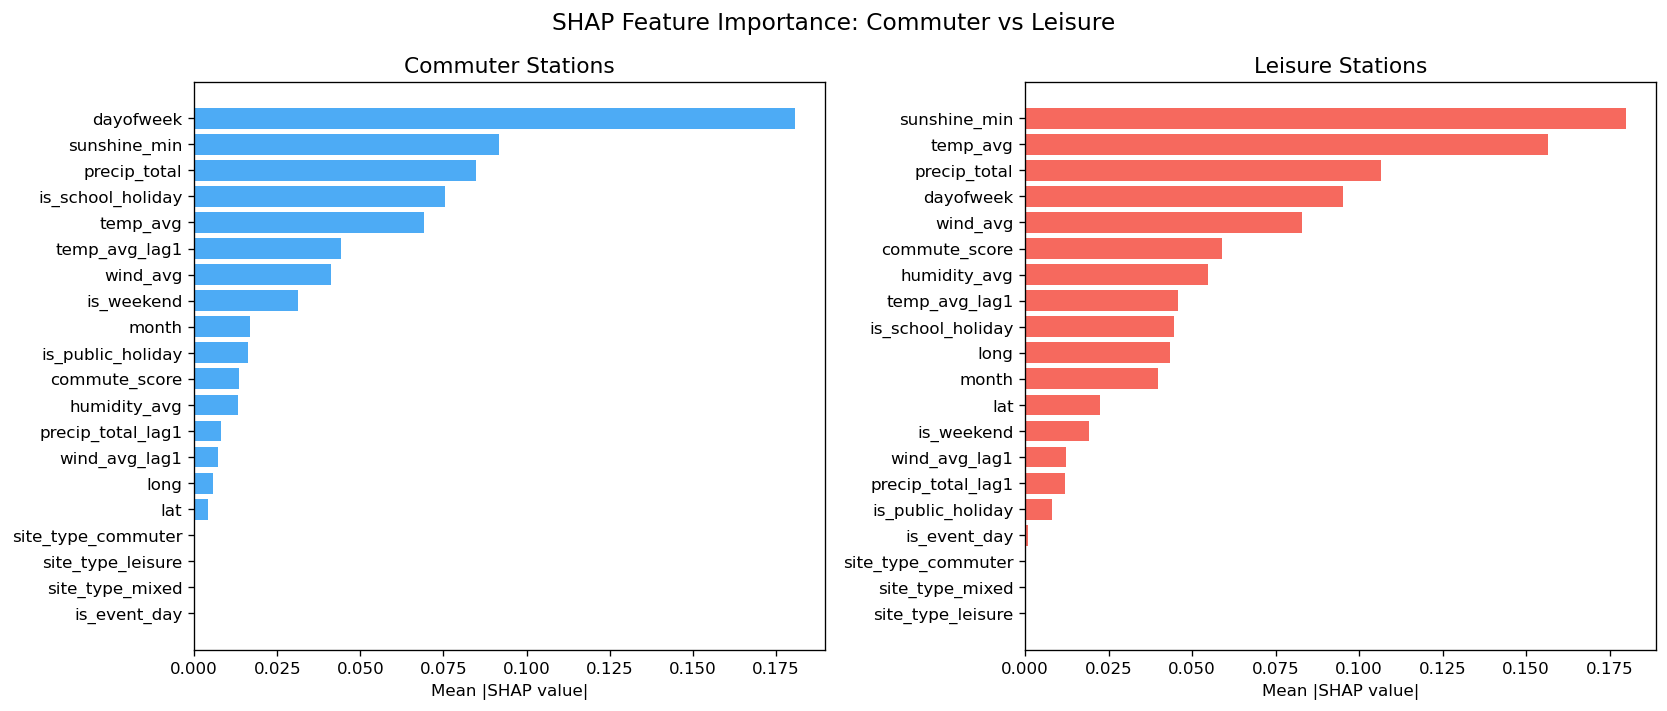

08c_shap_summary_comparison.png saved.


In [68]:
# Fig C — Commuter vs Leisure SHAP summary (side-by-side mean |SHAP| bar)
idx_shap_c = rng.choice(len(X_test_c), size=min(N_SHAP, len(X_test_c)), replace=False)
X_shap_c   = X_test_c[idx_shap_c]

idx_shap_l = rng.choice(len(X_test_l), size=min(N_SHAP, len(X_test_l)), replace=False)
X_shap_l   = X_test_l[idx_shap_l]

explainer_c   = shap.TreeExplainer(xgb_commuter)
shap_values_c = explainer_c.shap_values(X_shap_c)

explainer_l   = shap.TreeExplainer(xgb_leisure)
shap_values_l = explainer_l.shap_values(X_shap_l)

fig_c, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 6))

for ax, shap_vals, title, color in [
    (ax_left,  shap_values_c, "Commuter Stations", COLORS["commuter"]),
    (ax_right, shap_values_l, "Leisure Stations",  COLORS["leisure"]),
]:
    mean_abs = np.abs(shap_vals).mean(axis=0)
    order = np.argsort(mean_abs)
    ax.barh(
        [ALL_FEATURES[i] for i in order],
        mean_abs[order],
        color=color,
        alpha=0.8,
    )
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(title, fontsize=13)

fig_c.suptitle("SHAP Feature Importance: Commuter vs Leisure", fontsize=14)
fig_c.tight_layout()
fig_c.savefig(FIGS / "08c_shap_summary_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("08c_shap_summary_comparison.png saved.")

## 7. Weather Effect Sizes

Reference: temp=15\u00b0C, precip=0mm, wind=10km/h, sunshine=300min, humidity=70%,
lag features same as reference, Wednesday (dayofweek=2), June, no calendar flags.

In [69]:
REF = {
    "temp_avg"         : 15.0,
    "precip_total"     : 0.0,
    "wind_avg"         : 10.0,
    "sunshine_min"     : 300.0,
    "humidity_avg"     : 70.0,
    "temp_avg_lag1"    : 15.0,
    "precip_total_lag1": 0.0,
    "wind_avg_lag1"    : 10.0,
    "dayofweek"        : 2,
    "month"            : 6,
    "is_weekend"       : 0,
    "is_public_holiday": 0,
    "is_school_holiday": 0,
    "is_event_day"     : 0,
    "commute_score"    : float(train_clean_full["commute_score"].median()),
    "lat"              : float(train_clean_full["lat"].median()),
    "long"             : float(train_clean_full["long"].median()),
}
for _col in SITE_TYPE_COLS:
    REF[_col] = float(train_clean_full[_col].mean())

median_offset_full = train_clean_full["site_offset"].median()
median_offset_c    = train_clean_c["site_offset"].median()
median_offset_l    = train_clean_l["site_offset"].median()

def weather_effect_xgb(model, feature, bad_val, ref_val, offset):
    base = np.array([[REF[f] for f in ALL_FEATURES]] * 100, dtype=float)
    feat_idx = ALL_FEATURES.index(feature)
    X_bad = base.copy(); X_bad[:, feat_idx] = bad_val
    X_ref = base.copy(); X_ref[:, feat_idx] = ref_val
    y_bad = np.expm1(model.predict(X_bad) + offset).mean()
    y_ref = np.expm1(model.predict(X_ref) + offset).mean()
    return (y_bad - y_ref) / y_ref * 100

comparisons = [
    ("Heavy rain (20mm vs 0mm)",    "precip_total",  20.0,   0.0),
    ("Light rain (2mm vs 0mm)",     "precip_total",   2.0,   0.0),
    ("Cold day (0°C vs 15°C)",      "temp_avg",       0.0,  15.0),
    ("Cool day (8°C vs 15°C)",      "temp_avg",       8.0,  15.0),
    ("Strong wind (40 vs 10 km/h)", "wind_avg",      40.0,  10.0),
    ("No sunshine (0 vs 300 min)",  "sunshine_min",   0.0, 300.0),
]

print("=" * 69)
print("XGBOOST WEATHER EFFECT SIZES")
print("=" * 69)
print(f"{'Condition':<35} | {'Full':>7} | {'Commuter':>9} | {'Leisure':>8}")
print("-" * 69)

eff_results = []
for label, feat, bad_val, ref_val in comparisons:
    eff_f = weather_effect_xgb(xgb_full,     feat, bad_val, ref_val, median_offset_full)
    eff_c = weather_effect_xgb(xgb_commuter, feat, bad_val, ref_val, median_offset_c)
    eff_l = weather_effect_xgb(xgb_leisure,  feat, bad_val, ref_val, median_offset_l)
    eff_results.append((label, eff_f, eff_c, eff_l))
    print(f"{label:<35} | {eff_f:>6.1f}% | {eff_c:>8.1f}% | {eff_l:>7.1f}%")

XGBOOST WEATHER EFFECT SIZES
Condition                           |    Full |  Commuter |  Leisure
---------------------------------------------------------------------
Heavy rain (20mm vs 0mm)            |  -28.6% |    -26.6% |   -23.7%
Light rain (2mm vs 0mm)             |  -15.3% |    -13.0% |   -21.4%
Cold day (0°C vs 15°C)              |  -20.9% |    -16.3% |   -34.7%
Cool day (8°C vs 15°C)              |  -13.3% |     -8.9% |   -27.9%
Strong wind (40 vs 10 km/h)         |  -15.4% |    -11.2% |   -22.1%
No sunshine (0 vs 300 min)          |   -9.8% |     -4.6% |   -12.0%


## 8. Normalized Cycling Index

Replace actual weather with reference conditions; predict with Full XGBoost.
The normalized count shows underlying demand stripped of weather variation.

Saved: normalized_cycling_index_xgb.csv


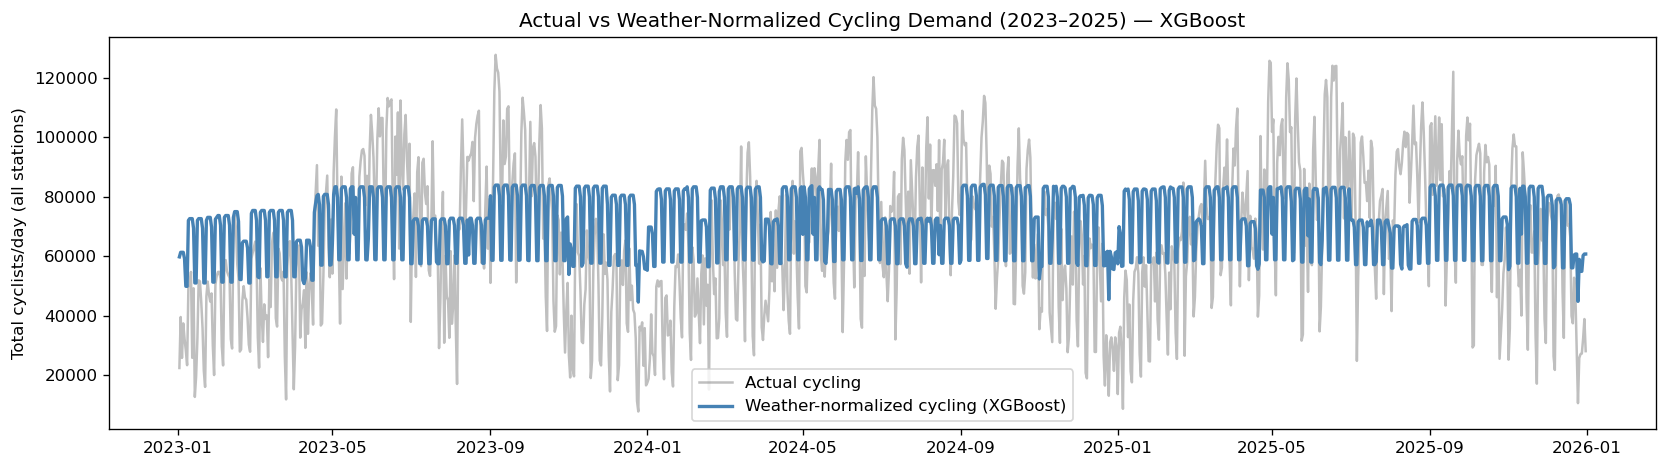

08c_normalized_vs_actual.png saved.


In [70]:
REF_WEATHER = {
    "temp_avg"         : 15.0,
    "precip_total"     : 0.0,
    "wind_avg"         : 10.0,
    "sunshine_min"     : 300.0,
    "humidity_avg"     : 70.0,
    "temp_avg_lag1"    : 15.0,
    "precip_total_lag1": 0.0,
    "wind_avg_lag1"    : 10.0,
}

panel_norm = panel_good.copy()
panel_norm["date"] = pd.to_datetime(panel_norm["date"])
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    panel_norm[col] = panel_norm[col].astype(int)

cols_needed  = ALL_FEATURES + ["site_offset"]
extra_cols   = ["site ID", "naam", "date", "aantal", "site_type", "day_type", "season"]
avail_extra  = [c for c in extra_cols if c in panel_norm.columns]
panel_norm_clean = panel_norm[cols_needed + avail_extra].dropna(subset=cols_needed)

X_norm = panel_norm_clean[ALL_FEATURES].values.copy().astype(float)
for feat, val in REF_WEATHER.items():
    X_norm[:, ALL_FEATURES.index(feat)] = val

offset = panel_norm_clean["site_offset"].values
y_adj_pred = xgb_full.predict(X_norm)
panel_norm_clean = panel_norm_clean.copy()
panel_norm_clean["normalized_count"] = np.clip(np.expm1(y_adj_pred + offset), 0, None)

out_cols = ["site ID", "naam", "date", "aantal", "normalized_count"] + \
           [c for c in ["site_type", "day_type", "season"] if c in panel_norm_clean.columns]
panel_norm_clean[out_cols].to_csv(
    PROCESSED / "normalized_cycling_index_xgb.csv", index=False
)
print("Saved: normalized_cycling_index_xgb.csv")

daily_actual = panel_norm_clean.groupby("date")["aantal"].sum()
daily_norm   = panel_norm_clean.groupby("date")["normalized_count"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_actual.index, daily_actual.values, alpha=0.5, color="gray", label="Actual cycling")
ax.plot(daily_norm.index,   daily_norm.values,   color="steelblue", linewidth=2,
        label="Weather-normalized cycling (XGBoost)")
ax.set_title("Actual vs Weather-Normalized Cycling Demand (2023\u20132025) \u2014 XGBoost")
ax.set_ylabel("Total cyclists/day (all stations)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "08c_normalized_vs_actual.png", dpi=150)
plt.show()
print("08c_normalized_vs_actual.png saved.")

## 9. Save Models

In [71]:
models = {
    "xgb_full"        : xgb_full,
    "xgb_commuter"    : xgb_commuter,
    "xgb_leisure"     : xgb_leisure,
    "site_offset_test": site_offset_test,
    "ALL_FEATURES"    : ALL_FEATURES,
}
with open(PROCESSED / "xgb_models.pkl", "wb") as fh:
    pickle.dump(models, fh)
print(f"Models saved to {PROCESSED / 'xgb_models.pkl'}")

Models saved to /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/data/processed/xgb_models.pkl


## 10. Final Summary

In [72]:
heavy_rain  = weather_effect_xgb(xgb_full, "precip_total",  20.0,   0.0, median_offset_full)
cold_day    = weather_effect_xgb(xgb_full, "temp_avg",       0.0,  15.0, median_offset_full)
strong_wind = weather_effect_xgb(xgb_full, "wind_avg",      40.0,  10.0, median_offset_full)

print("=" * 54)
print("XGBOOST MODELLING SUMMARY")
print("=" * 54)
print(f"Training period : 2023–2024 ({len(y_train_full):,} observations)")
print(f"Test period     : 2025     ({len(y_test_full):,} observations)")
print()
print("Model performance (test set):")
print(f"  Full XGB     : MAE={test_mae:.1f}, R²={test_r2:.3f}")
print(f"  Commuter XGB : MAE={mae_c:.1f}, R²={r2_c:.3f}")
print(f"  Leisure XGB  : MAE={mae_l:.1f}, R²={r2_l:.3f}")
print()
print("Key weather effects (full model):")
print(f"  Heavy rain (20mm) : {heavy_rain:+.1f}%")
print(f"  Cold day (0°C)    : {cold_day:+.1f}%")
print(f"  Strong wind       : {strong_wind:+.1f}%")
print("=" * 54)

XGBOOST MODELLING SUMMARY
Training period : 2023–2024 (96,038 observations)
Test period     : 2025     (48,151 observations)

Model performance (test set):
  Full XGB     : MAE=130.0, R²=0.853
  Commuter XGB : MAE=132.1, R²=0.875
  Leisure XGB  : MAE=116.2, R²=0.813

Key weather effects (full model):
  Heavy rain (20mm) : -28.6%
  Cold day (0°C)    : -20.9%
  Strong wind       : -15.4%
